### Testing Our Previous Implementation

In [1]:
import torch
from gpt_modules import GPTModel

# Our implementation actually allows defining separate dropout rates, but defaults to "drop_rate" when specific rates are not available
GPT_CONFIG_124M = {
    "vocab_size": 50_257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [2]:
from gpt_modules import generate_text_simple
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print(f"Output text:\n{token_ids_to_text(token_ids, tokenizer)}")

Output text:
Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### Training

#### Evaluation

In [3]:
inputs = torch.vstack([
    text_to_token_ids("every effort moves", tokenizer),
    text_to_token_ids("I really like", tokenizer)
])

targets = torch.vstack([
    text_to_token_ids(" effort moves you", tokenizer),
    text_to_token_ids(" really like chocolate", tokenizer)
])

print(inputs.shape)
print(targets.shape)

torch.Size([2, 3])
torch.Size([2, 3])


In [4]:
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [5]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print(f"Token IDs:\n {token_ids}")

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [6]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:", f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:   Armed heNetflix


In [7]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()
print(f"Flattened logits: {logits_flat.shape}")
print(f"Flattened targets: {targets_flat.shape}")

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [8]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
loss

tensor(10.7940)

In [9]:
perplexity = torch.exp(loss) # Using the exp(cross-entropy) version because torch cross-entropy uses natural log (vs. e.g. another common log2 usage)
perplexity

tensor(48725.8203)

In [10]:
file_path = "../data/the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [11]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print(f"Characters: {total_characters}")
print(f"Tokens: {total_tokens}")

Characters: 20479
Tokens: 5145


#### Training

In [12]:
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [13]:
from data_utils import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    txt=train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    txt=val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [14]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [15]:
print("Validation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [16]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [17]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i , (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [18]:
device = torch.device("cuda")

In [19]:
model.to(device)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print(f"Training loss:{ train_loss}")
print(f"Validation loss: {val_loss}")

Training loss:10.98758347829183
Validation loss: 10.98110580444336


In [20]:
model.pos_emb.weight

Parameter containing:
tensor([[ 0.8769,  0.2550,  0.8441,  ..., -1.0354,  1.3085,  1.7957],
        [-1.0029,  0.0995,  1.2459,  ...,  1.5453, -0.1126, -1.5197],
        [ 1.3317,  0.7561,  0.9077,  ...,  0.0830,  1.8336, -2.2225],
        ...,
        [ 1.1003, -0.5333,  0.5827,  ...,  0.7884,  1.1323, -0.3501],
        [ 1.0171,  0.3694, -1.3678,  ..., -0.6988, -0.9380, -1.0564],
        [-0.5017,  0.7875,  1.0353,  ...,  1.8956, -0.9677, -0.1236]],
       device='cuda:0', requires_grad=True)

In [21]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
        model.train()
        return train_loss, val_loss
    
def generate_and_print_sample(
        model, tokenizer, device, start_context
):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [22]:
def train_model_simple(
        model,
        train_loader,
        val_loader,
        optimizer,
        device,
        num_epochs,
        eval_freq,
        eval_iter,
        start_context,
        tokenizer
):
    train_losses, val_losses, track_tokens_seen = list(),list(), list()
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch=input_batch,
                target_batch=target_batch,
                model=model,
                device=device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}"
                      f"Val loss {val_loss:.3f}")
                    
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    return train_losses, val_losses, track_tokens_seen


In [23]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=4e-4, weight_decay=1e-1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.823Val loss 9.932
Ep 1 (Step 000005): Train loss 8.065Val loss 8.336
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.621Val loss 7.051
Ep 2 (Step 000015): Train loss 6.043Val loss 6.599
Every effort moves you, and,, and,, and,,,, and, and,,,,,,,,, and,,,, the,,,, and,, and,,, the, and,,,,,,
Ep 3 (Step 000020): Train loss 5.547Val loss 6.485
Ep 3 (Step 000025): Train loss 5.450Val loss 6.397
Every effort moves you, and to the to the of the to the, and I had. Gis, and, and, and, and, and, and I had, and, and, and, and, and, and, and, and, and,
Ep 4 (Step 000030): Train loss 4.982Val loss 6.301
Ep 4 (Step 000035): Train loss 4.755Val loss 6.296
Every effort moves you, and I had been the of the picture to the picture.                                     
Ep 5 (Step 000040): Train loss 4.162Val loss 6.182
Every effort moves you know the                                                
Ep 6 (Step 000045

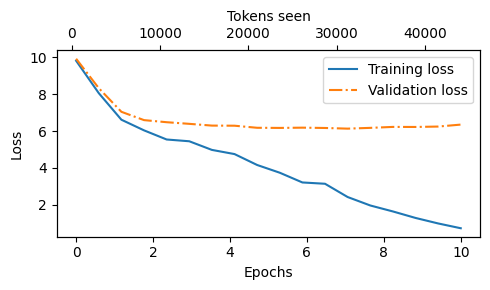

In [24]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)


## Decoding Strategies

In [25]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [26]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=100,
    context_size=GPT_CONFIG_124M["context_length"]
)
print(f"Output text: {token_ids_to_text(token_ids, tokenizer)}")

Output text: Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"

He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I couldn't look at that thing--couldn't face it. But I forced myself to put it here; and now it's cured me--cured me. But no--for it was not till after that event that the _rose Dubarry


### Temperature Scaling

In [27]:
vocab = {
    word: i for i, word in enumerate(["closer", "every",
                                      "effort", "forward", "inches", "moves",
                                      "pizza", "toward", "you"])
}
inverse_vocab = {v:k for k, v in vocab.items()}

In [28]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [29]:
# Greedy decoding
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [30]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [31]:
print([f"{prob:.2f}" for prob in probas])

['0.06', '0.00', '0.00', '0.57', '0.00', '0.00', '0.00', '0.36', '0.00']


In [32]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for _ in range(1000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [33]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / (temperature + 1e-6)
    return torch.softmax(scaled_logits, dim=-1)

In [34]:
print("Temperature T = 1.0")
print([f"{prob:.2f}" for prob in softmax_with_temperature(next_token_logits, 1.0)]) # Not changing softmax outputs
print()
print("Temperature T = 2.0")
print([f"{prob:.2f}" for prob in softmax_with_temperature(next_token_logits, 2.0)]) # Dispersing the distribution, flattening it
print()
print("Temperature T = 0.1") # Smaller temperature -> Closer to greedy by creating a peak around the most likely token
print([f"{prob:.2f}" for prob in softmax_with_temperature(next_token_logits, 0.1)])

Temperature T = 1.0
['0.06', '0.00', '0.00', '0.57', '0.00', '0.00', '0.00', '0.36', '0.00']

Temperature T = 2.0
['0.14', '0.02', '0.01', '0.42', '0.03', '0.01', '0.01', '0.33', '0.04']

Temperature T = 0.1
['0.00', '0.00', '0.00', '0.99', '0.00', '0.00', '0.00', '0.01', '0.00']


In [35]:
print("Temperature T = 20.0") # Turns it almost completely into uniform
print([f"{prob:.2f}" for prob in softmax_with_temperature(next_token_logits, 20.0)]) # Dispersing the distribution, flattening it

Temperature T = 20.0
['0.13', '0.10', '0.09', '0.14', '0.11', '0.09', '0.09', '0.14', '0.11']


### Top-k Sampling

In [36]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [37]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [38]:
# That softmax trick is back at it again
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### Combining Temperature Scaling and Top-K Sampling

In [39]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:] # Take the last 'context_size' tokens
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :] # Get the last row from each batch, i.e. the predicted next token embedding
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1] # Get the smallest of the "max values"
            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf")).to(logits.device),
                logits
            )
        logits = logits/(temperature + 1e-6)
        probs = torch.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        if idx_next == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


In [40]:
# torch.manual_seed(123)
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k = 25,
    temperature=1.4
)

print(f"Output text:\n{token_ids_to_text(token_ids, tokenizer)}")

Output text:
Every effort moves you in the bitterness, when I felt able of the show, by his shoulders


## Persistence and then Loading OpenAI Weights

In [41]:
torch.save(model.state_dict(), "../models/model.pth")
del model
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("../models/model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [42]:
# For stateful optimizers, save with the optimizer
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),

    },
    "../models/model-and-optimizer.pth"
)

In [43]:
del model
checkpoint = torch.load("../models/model-and-optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

In [44]:
# Exercise 5.4
model.to(device)
num_epochs = 1
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 0.518Val loss 6.400
Ep 1 (Step 000005): Train loss 0.419Val loss 6.478
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I
